[ DATA ]
     feature_1  feature_2  feature_3      target
0    37.454012  37.926469  30.888505  256.613259
1    95.071431  31.443855  23.323278  426.810888
2    73.199394  22.381105  31.900989  366.514290
3    59.865848  42.551801  33.052929  368.131022
4    15.601864  37.389247  32.798952  158.933710
..         ...        ...        ...         ...
495  35.335223  13.663283  30.708585  164.062160
496  58.365611  46.692543  41.596648  344.765469
497   7.773464  15.472745  31.966589  105.176577
498  97.439481  48.009494  30.960246  472.764984
499  98.621074  27.840231  28.454418  426.225324

[500 rows x 4 columns]
[ R² SCORE ]


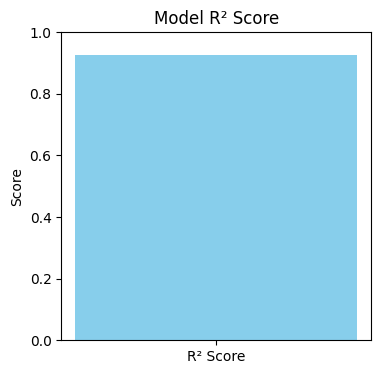

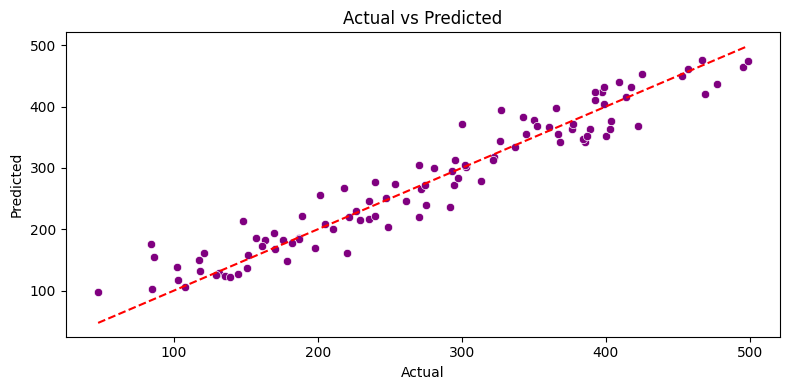

Mean Absolute Error: 23.82
Mean Squared Error: 935.73
Root Mean Squared Error: 30.59
R² Score: 0.93


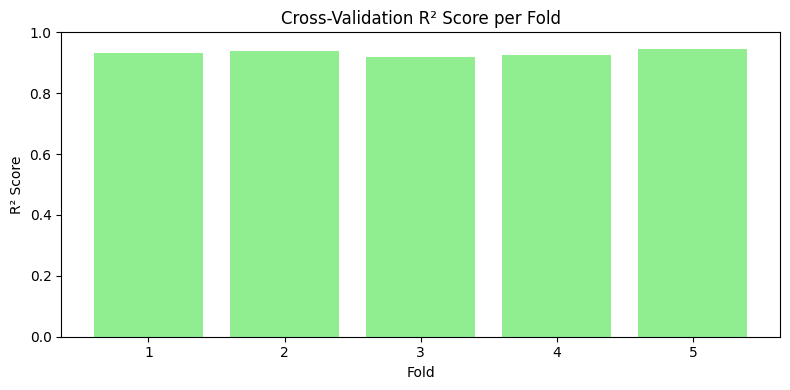

In [5]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor

# load & prepare data
data = pd.read_csv('../../CSV/regression_dataset.csv')
X = data.drop(columns='target')
y = data['target']

print("[ DATA ]")
print(data)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# test model
predictions = model.predict(X_test)

# evaluate model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

# save model
joblib.dump(model, 'models/random_forest_regressor.joblib')

# 1. R² Score - Bar Plot
print("[ R² SCORE ]")
plt.figure(figsize=(4, 4))
plt.bar(["R² Score"], [r2], color='skyblue')
plt.ylim(0, 1)
plt.title("Model R² Score")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Scatter Plot
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_test, y=predictions, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# 3. Print Error Metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 4. Cross-Validation Scores - R²
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation R² Score per Fold")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()